In [1]:
!pip install pandas seaborn scikit-learn

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("Loan_default.csv")

In [4]:
df.head()

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


In [5]:
df.columns

Index(['LoanID', 'Age', 'Income', 'LoanAmount', 'CreditScore',
       'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm',
       'DTIRatio', 'Education', 'EmploymentType', 'MaritalStatus',
       'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner',
       'Default'],
      dtype='str')

In [6]:
df.shape

(255347, 18)

In [7]:
df.isnull().sum()

LoanID            0
Age               0
Income            0
LoanAmount        0
CreditScore       0
MonthsEmployed    0
NumCreditLines    0
InterestRate      0
LoanTerm          0
DTIRatio          0
Education         0
EmploymentType    0
MaritalStatus     0
HasMortgage       0
HasDependents     0
LoanPurpose       0
HasCoSigner       0
Default           0
dtype: int64

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 255347 entries, 0 to 255346
Data columns (total 18 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   LoanID          255347 non-null  str    
 1   Age             255347 non-null  int64  
 2   Income          255347 non-null  int64  
 3   LoanAmount      255347 non-null  int64  
 4   CreditScore     255347 non-null  int64  
 5   MonthsEmployed  255347 non-null  int64  
 6   NumCreditLines  255347 non-null  int64  
 7   InterestRate    255347 non-null  float64
 8   LoanTerm        255347 non-null  int64  
 9   DTIRatio        255347 non-null  float64
 10  Education       255347 non-null  str    
 11  EmploymentType  255347 non-null  str    
 12  MaritalStatus   255347 non-null  str    
 13  HasMortgage     255347 non-null  str    
 14  HasDependents   255347 non-null  str    
 15  LoanPurpose     255347 non-null  str    
 16  HasCoSigner     255347 non-null  str    
 17  Default         25534

# EDA 

In [10]:
df.head()

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


In [11]:
df[df['Default'] == 1]['Age'].value_counts().sort_index()

Age
18    1084
19    1096
20    1086
21     992
22    1100
23     887
24     943
25     912
26     887
27     905
28     876
29     788
30     769
31     788
32     781
33     745
34     709
35     696
36     688
37     629
38     650
39     571
40     573
41     536
42     549
43     509
44     494
45     485
46     478
47     468
48     439
49     433
50     458
51     408
52     394
53     344
54     388
55     343
56     360
57     318
58     297
59     286
60     277
61     266
62     269
63     243
64     268
65     291
66     217
67     231
68     235
69     214
Name: count, dtype: int64

In [12]:
df[df['Default']==1]['Education'].value_counts()

Education
High School    8230
Bachelor's     7789
Master's       6908
PhD            6726
Name: count, dtype: int64

In [13]:
num_cols = df.select_dtypes(include=['int64','float64']).columns
cat_cols = df.select_dtypes(include=['str']).columns

print("Numerical columns:", num_cols)
print("Categorical columns:", cat_cols)

Numerical columns: Index(['Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed',
       'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio', 'Default'],
      dtype='str')
Categorical columns: Index(['LoanID', 'Education', 'EmploymentType', 'MaritalStatus', 'HasMortgage',
       'HasDependents', 'LoanPurpose', 'HasCoSigner'],
      dtype='str')


In [14]:
df.duplicated().sum()

0

In [15]:
df['Default'].value_counts()

Default
0    225694
1     29653
Name: count, dtype: int64

C:\Users\Aniket\AppData\Local\Temp\ipykernel_22944\1123939555.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Default', data=df,palette='plasma')


<Axes: xlabel='Default', ylabel='count'>

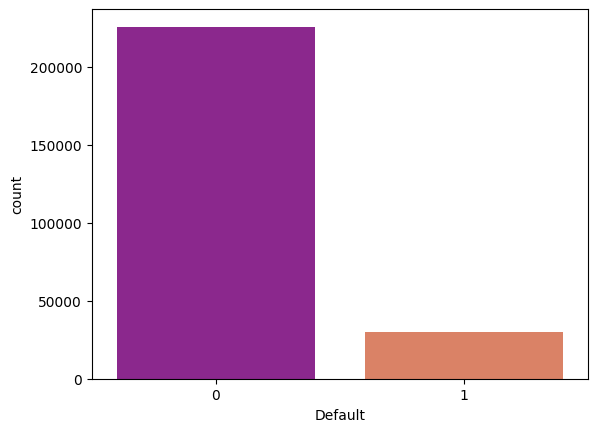

In [16]:
sns.countplot(x='Default', data=df,palette='plasma')

<Axes: ylabel='Income'>

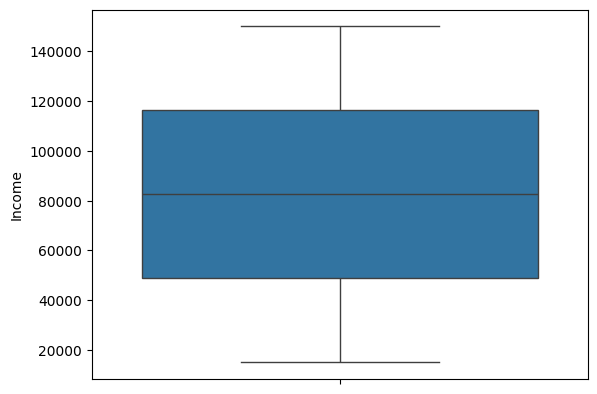

In [17]:
sns.boxplot(y=df['Income'])


<Axes: xlabel='CreditScore', ylabel='Count'>

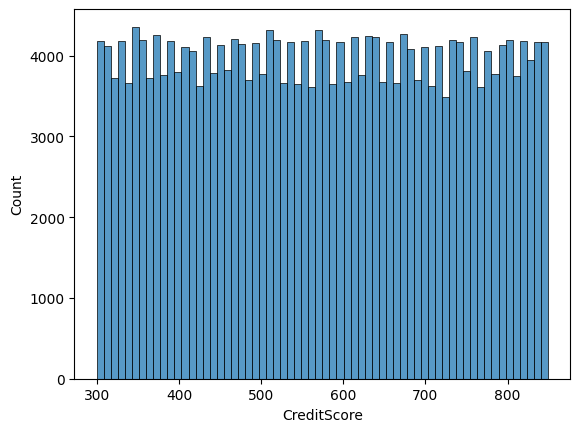

In [18]:
sns.histplot(x=df['CreditScore'],data=df)

In [19]:
import pandas as pd
import seaborn as sns

print(pd.__version__)
print(sns.__version__)

3.0.2
0.13.2


In [20]:
def analyze_num(col):
    fig, axes = plt.subplots(1,2, figsize=(12,4))
    
    sns.histplot(df[col], bins=30, ax=axes[0])
    axes[0].set_title(f"{col} Distribution")
    
    sns.boxplot(x=df[col], ax=axes[1])
    axes[1].set_title(f"{col} Boxplot")
    
    plt.show()

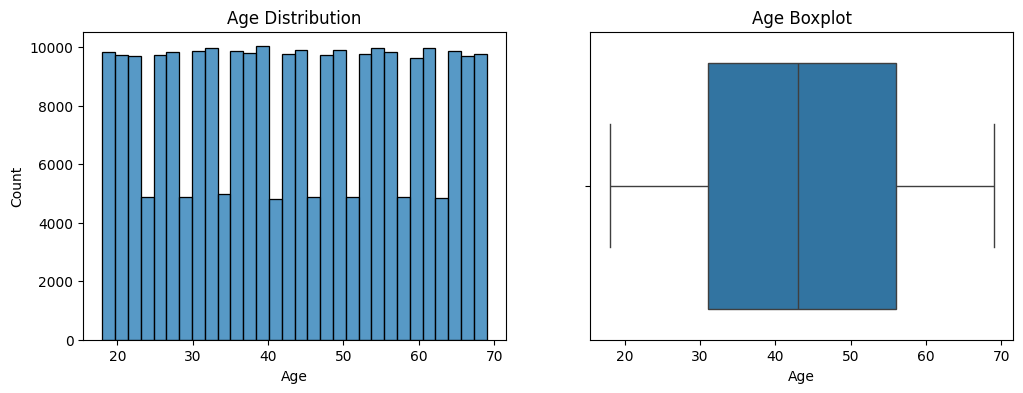

In [21]:
analyze_num('Age')

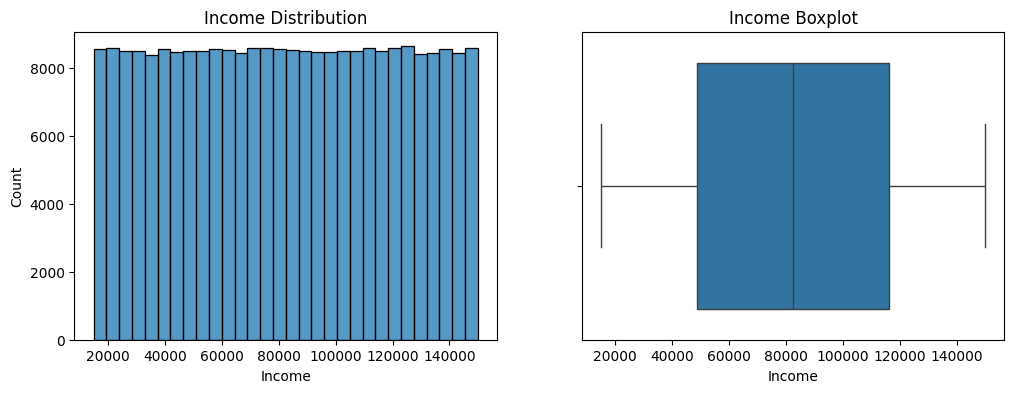

In [22]:
analyze_num('Income')

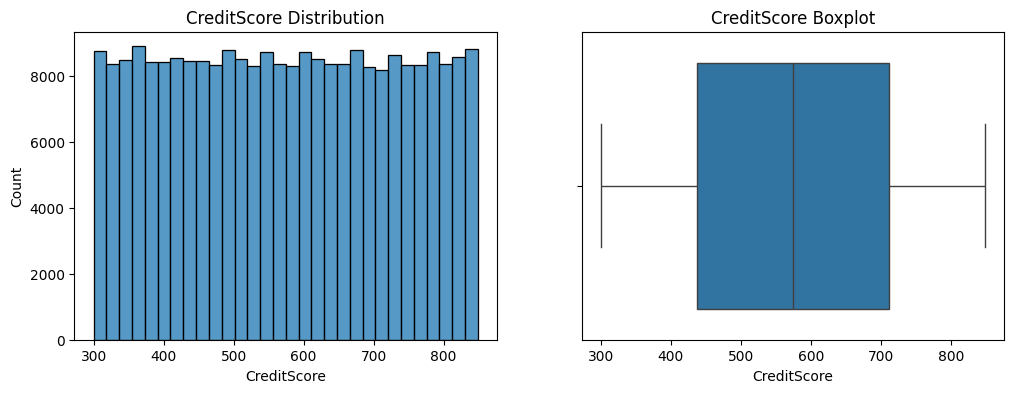

In [23]:
analyze_num('CreditScore')

In [24]:
def analyze_cat(col):
    plt.figure(figsize=(8,4))
    sns.countplot(x=col, data=df)
    plt.xticks(rotation=45)
    plt.show()

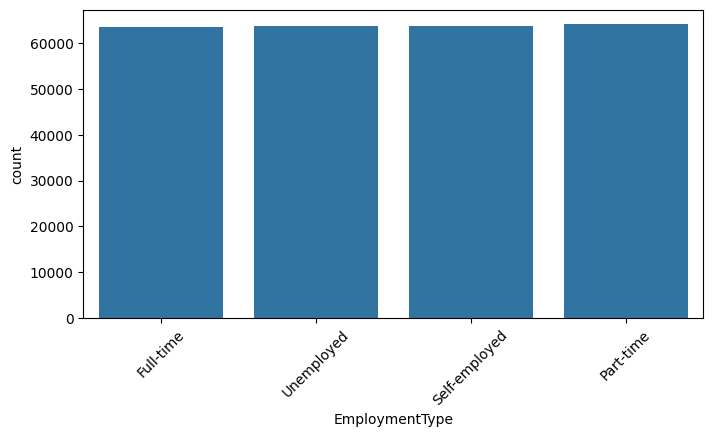

In [25]:
analyze_cat('EmploymentType')

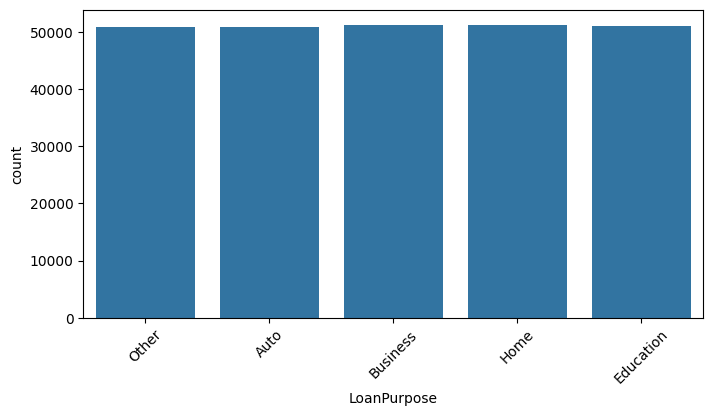

In [26]:
analyze_cat('LoanPurpose')


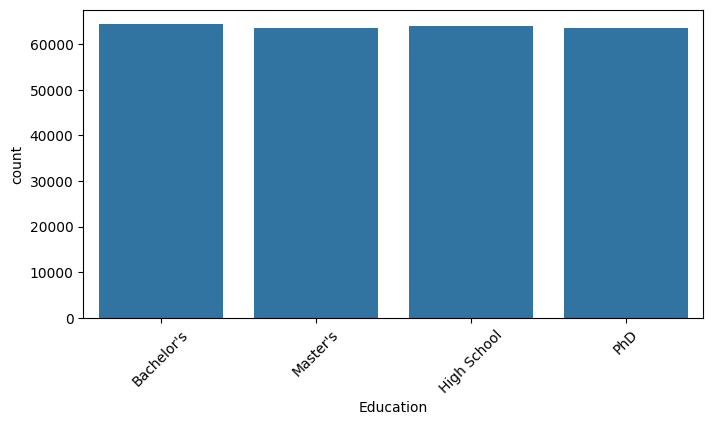

In [27]:
analyze_cat('Education')

In [28]:
bins = [18,25,35,50,70]
labels = ['18-25','26-35','36-50','51+']

df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels)


<Axes: xlabel='AgeGroup', ylabel='Default'>

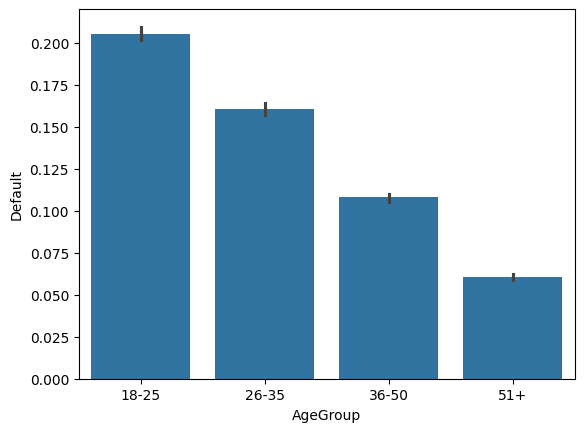

In [29]:
sns.barplot(x='AgeGroup', y='Default', data=df)

<Axes: xlabel='Default', ylabel='CreditScore'>

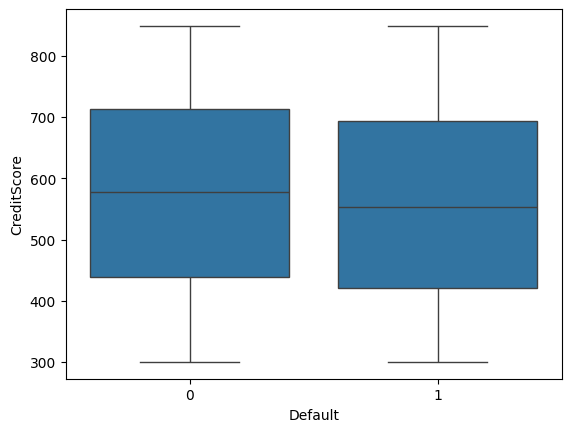

In [30]:
sns.boxplot(x='Default', y='CreditScore', data=df)

<Axes: xlabel='Default', ylabel='Income'>

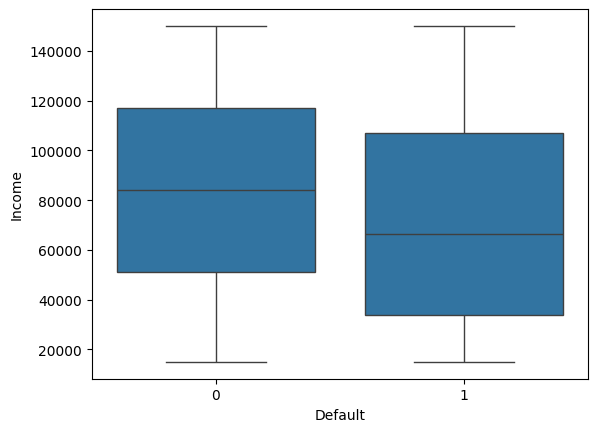

In [31]:
sns.boxplot(x='Default', y='Income', data=df)

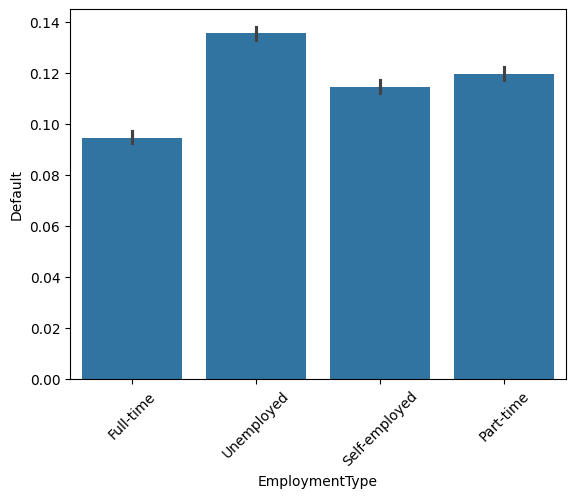

In [32]:
sns.barplot(x='EmploymentType', y='Default', data=df)
plt.xticks(rotation=45)
plt.show()

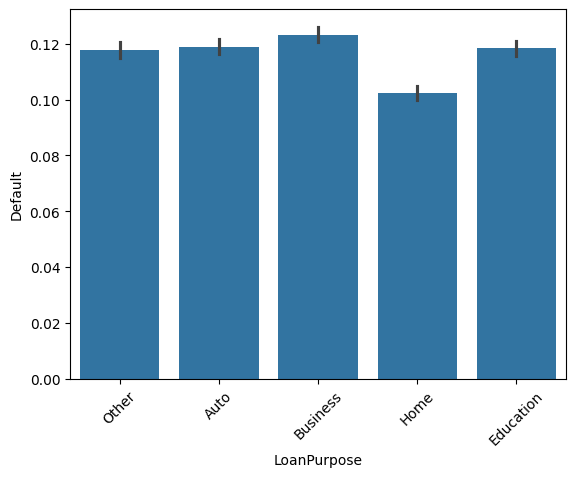

In [33]:
sns.barplot(x='LoanPurpose', y='Default', data=df)
plt.xticks(rotation=45)
plt.show()

In [67]:
df.head()

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default,AgeGroup
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0,51+
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0,51+
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1,36-50
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0,26-35
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0,51+


In [69]:
df['interestRate']

KeyError: 'interestRate'